In [265]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [266]:
#En caso de no poder cargar el archivo con seaborns leerlo con pandas
df= pd.read_csv("Canales.csv", header=None)

In [267]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 68 entries, 0 to 67
Data columns (total 60 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       47 non-null     str    
 1   1       37 non-null     str    
 2   2       38 non-null     str    
 3   3       40 non-null     str    
 4   4       40 non-null     str    
 5   5       41 non-null     str    
 6   6       42 non-null     str    
 7   7       41 non-null     str    
 8   8       42 non-null     str    
 9   9       41 non-null     str    
 10  10      41 non-null     str    
 11  11      42 non-null     str    
 12  12      43 non-null     str    
 13  13      46 non-null     str    
 14  14      46 non-null     str    
 15  15      46 non-null     str    
 16  16      46 non-null     str    
 17  17      43 non-null     str    
 18  18      43 non-null     str    
 19  19      45 non-null     str    
 20  20      45 non-null     str    
 21  21      45 non-null     str    
 22  22      45 non-

In [268]:
# Meses y años de las 24 columnas (12 de 2025 + 12 de 2026)
meses = df.iloc[6, 1:31].tolist()

In [269]:
#Dividir por secciones
#Piso
piso = df.loc[[7, 8, 9, 10, 11, 12, 13, 14, 15], 0:30].set_index(0).T
piso.columns = piso.columns.str.strip()
piso.columns.name = None
piso['Periodo'] = meses
piso['Canal'] = 'Piso'

# plazas
plazas = df.loc[[20, 21, 22, 23, 24, 26, 28, 29, 30], 0:30].set_index(0).T
plazas.columns = plazas.columns.str.strip()
plazas.columns.name = None
plazas['Periodo'] = meses
plazas['Canal'] = 'Plazas'

# digital
digital = df.loc[[35, 36, 37, 38, 39, 40, 41, 42, 43], 0:30].set_index(0).T
digital.columns = digital.columns.str.strip()
digital.columns.name = None
digital['Periodo'] = meses
digital['Canal'] = 'Digital'



In [270]:
# Unir las secciones
df = pd.concat([piso, plazas, digital], ignore_index=True)

In [271]:
# Limpiar %
df[['Conversion', 'Aporte']] = df[['Conversion', 'Aporte']].replace('%', '', regex=True).astype(float) / 100

# Limpiar "-"
df = df.replace('-', pd.NA)

#Pasar a numericas
cols_num = ['Leads', 'Efectivos', 'SDC', 'PDM', 'Citas Programadas', 'Citas Efectivas', 'Ventas']
df[cols_num] = df[cols_num].apply(pd.to_numeric, errors='coerce')

# Espacios en nombres de columnas
df.columns = df.columns.str.strip()



In [272]:
# Verificar otra vez
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Leads              90 non-null     int64  
 1   Efectivos          43 non-null     float64
 2   SDC                64 non-null     float64
 3   PDM                81 non-null     float64
 4   Citas Programadas  88 non-null     float64
 5   Citas Efectivas    87 non-null     float64
 6   Ventas             86 non-null     float64
 7   Conversion         90 non-null     float64
 8   Aporte             90 non-null     float64
 9   Periodo            90 non-null     str    
 10  Canal              90 non-null     str    
dtypes: float64(8), int64(1), str(2)
memory usage: 7.9 KB


In [273]:
df.to_csv("canales_limpio.csv", index=False)

In [274]:
df2 = df[['Ventas', 'Leads', 'Efectivos', 'SDC', 'PDM', 'Citas Programadas', 'Citas Efectivas', "Canal"]]

In [275]:
#Filtrar filas sin nulos en las columnas que usa el modelo
df2 = df2.dropna(subset=['PDM', 'Ventas'])

<Axes: xlabel='PDM', ylabel='Ventas'>

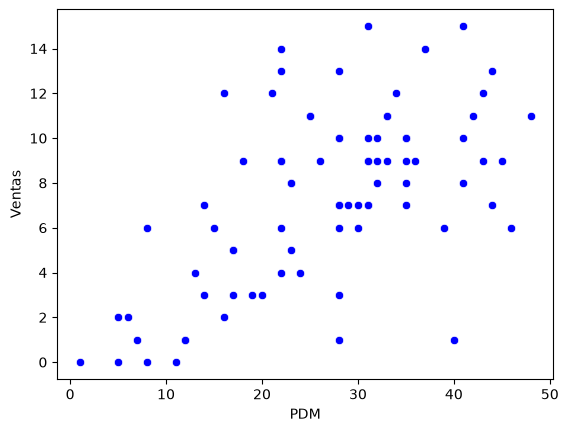

In [276]:
#Imprimimos el scatter plot entre la variable dependiente (total) e independiente (efectivos) 
#para observar el comportamiento en su dispersión 
from turtle import color
sns.scatterplot(x='PDM', y='Ventas', color="blue", data=df2)

In [277]:
#Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= df2[['PDM']]
Var_Dep= df2['Ventas']

In [278]:
# Se define model como la función de regresión lineal
from sklearn.linear_model import LinearRegression
model= LinearRegression()

In [279]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.21]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['PDM']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.833
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [280]:
# Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'tol': 1e-06,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['PDM'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([0.20835036]),
 'rank_': np.int64(1),
 'singular_': array([98.9253366]),
 'intercept_': np.float64(1.8328817031755396)}

In [281]:
# Modelo matemático:
# y= 0.20835036(PDM)+1.8328817031755396

In [282]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.34918020751643963

In [303]:
#Predecimos los valores de formalizado a partir de la variable "PDM"
y_pred= model.predict(X=df2[['PDM']])
y_pred

array([ 6.41658971,  4.54143644,  9.12514445, 10.16689627,  7.6666919 ,
        9.12514445,  8.29174299,  7.6666919 ,  4.7497868 ,  7.04164081,
        8.50009335,  7.6666919 ,  8.70844372,  8.50009335,  7.6666919 ,
        8.91679408,  8.29174299,  7.87504226, 11.00029772,  8.29174299,
       11.83369918, 10.79194736,  6.41658971, 11.41699845,  7.6666919 ,
       10.37524663,  9.33349481, 11.20864809, 10.58359699,  5.16648753,
        2.04123207,  4.12473571,  2.87463352,  3.08298389,  5.37483789,
        3.49968462,  2.87463352,  5.79153862,  4.7497868 ,  6.41658971,
        7.6666919 ,  5.99988898,  6.62494008,  6.62494008, 11.00029772,
        9.54184517,  8.08339263, 10.37524663, 10.79194736,  8.70844372,
        5.58318826,  4.95813716,  9.9585459 ,  9.12514445,  8.08339263,
        8.29174299, 10.37524663,  4.33308607,  3.49968462,  3.29133425,
        5.37483789,  7.6666919 ,  6.41658971,  6.83329044,  5.16648753,
        5.37483789,  7.24999117,  6.20823935,  8.70844372,  8.29

In [284]:
# Insertamos la columna de predicciones en el DataFrame
df2.insert(0, 'Predicciones', y_pred)
df2

,Predicciones,Ventas,Leads,Efectivos,SDC,PDM,Citas Programadas,Citas Efectivas,Canal
0,6.416590,9.0,329,NaN,NaN,22.0,9.0,4.0,Piso
1,4.541436,4.0,19,NaN,NaN,13.0,28.0,16.0,Piso
2,9.125144,10.0,76,NaN,NaN,35.0,15.0,6.0,Piso
3,10.166896,1.0,87,NaN,NaN,40.0,38.0,16.0,Piso
4,7.666692,3.0,55,NaN,NaN,28.0,78.0,60.0,Piso
...,...,...,...,...,...,...,...,...,...
85,7.041641,11.0,980,618.0,16.0,25.0,78.0,36.0,Digital
86,9.125144,8.0,834,179.0,32.0,35.0,83.0,59.0,Digital
87,9.125144,9.0,667,170.0,30.0,35.0,140.0,103.0,Digital
88,7.666692,7.0,748,200.0,28.0,28.0,101.0,53.0,Digital


In [285]:
piso = df2[df2['Canal'] == 'Piso']
plazas = df2[df2['Canal'] == 'Plazas']
digital = df2[df2['Canal'] == 'Digital']

<Axes: xlabel='PDM', ylabel='Ventas'>

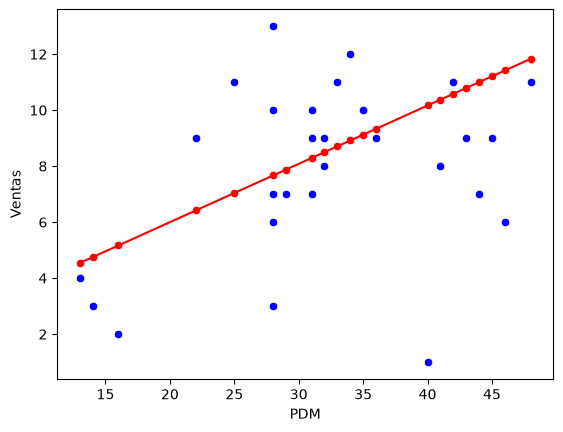

In [286]:
#Visualizamos la gráfica comparativa, por canal:piso
sns.scatterplot(x='PDM', y='Ventas', color="blue", data=piso)
sns.scatterplot(x='PDM', y='Predicciones', color="red", data=piso)
sns.lineplot(x='PDM', y='Predicciones', color="red", data=piso)

<Axes: xlabel='PDM', ylabel='Ventas'>

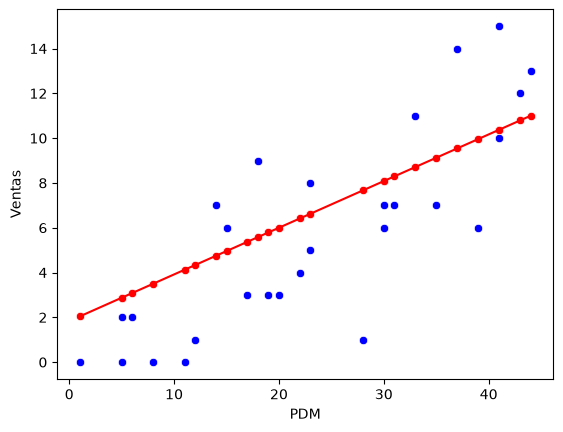

In [287]:
#Visualizamos la gráfica comparativa, por canal:plazas
sns.scatterplot(x='PDM', y='Ventas', color="blue", data=plazas)
sns.scatterplot(x='PDM', y='Predicciones', color="red", data=plazas)
sns.lineplot(x='PDM', y='Predicciones', color="red", data=plazas)

<Axes: xlabel='PDM', ylabel='Ventas'>

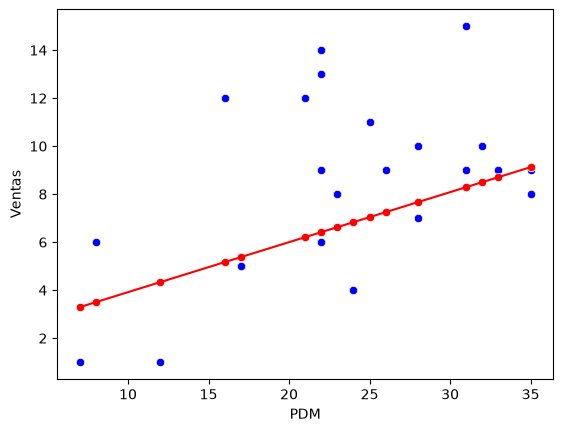

In [288]:
#Visualizamos la gráfica comparativa, por canal:digital
sns.scatterplot(x='PDM', y='Ventas', color="blue", data=digital)
sns.scatterplot(x='PDM', y='Predicciones', color="red", data=digital)
sns.lineplot(x='PDM', y='Predicciones', color="red", data=digital)

In [289]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
coef_Deter

0.34918020751643963

In [290]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
coef_Correl

np.float64(0.5909147210185575)

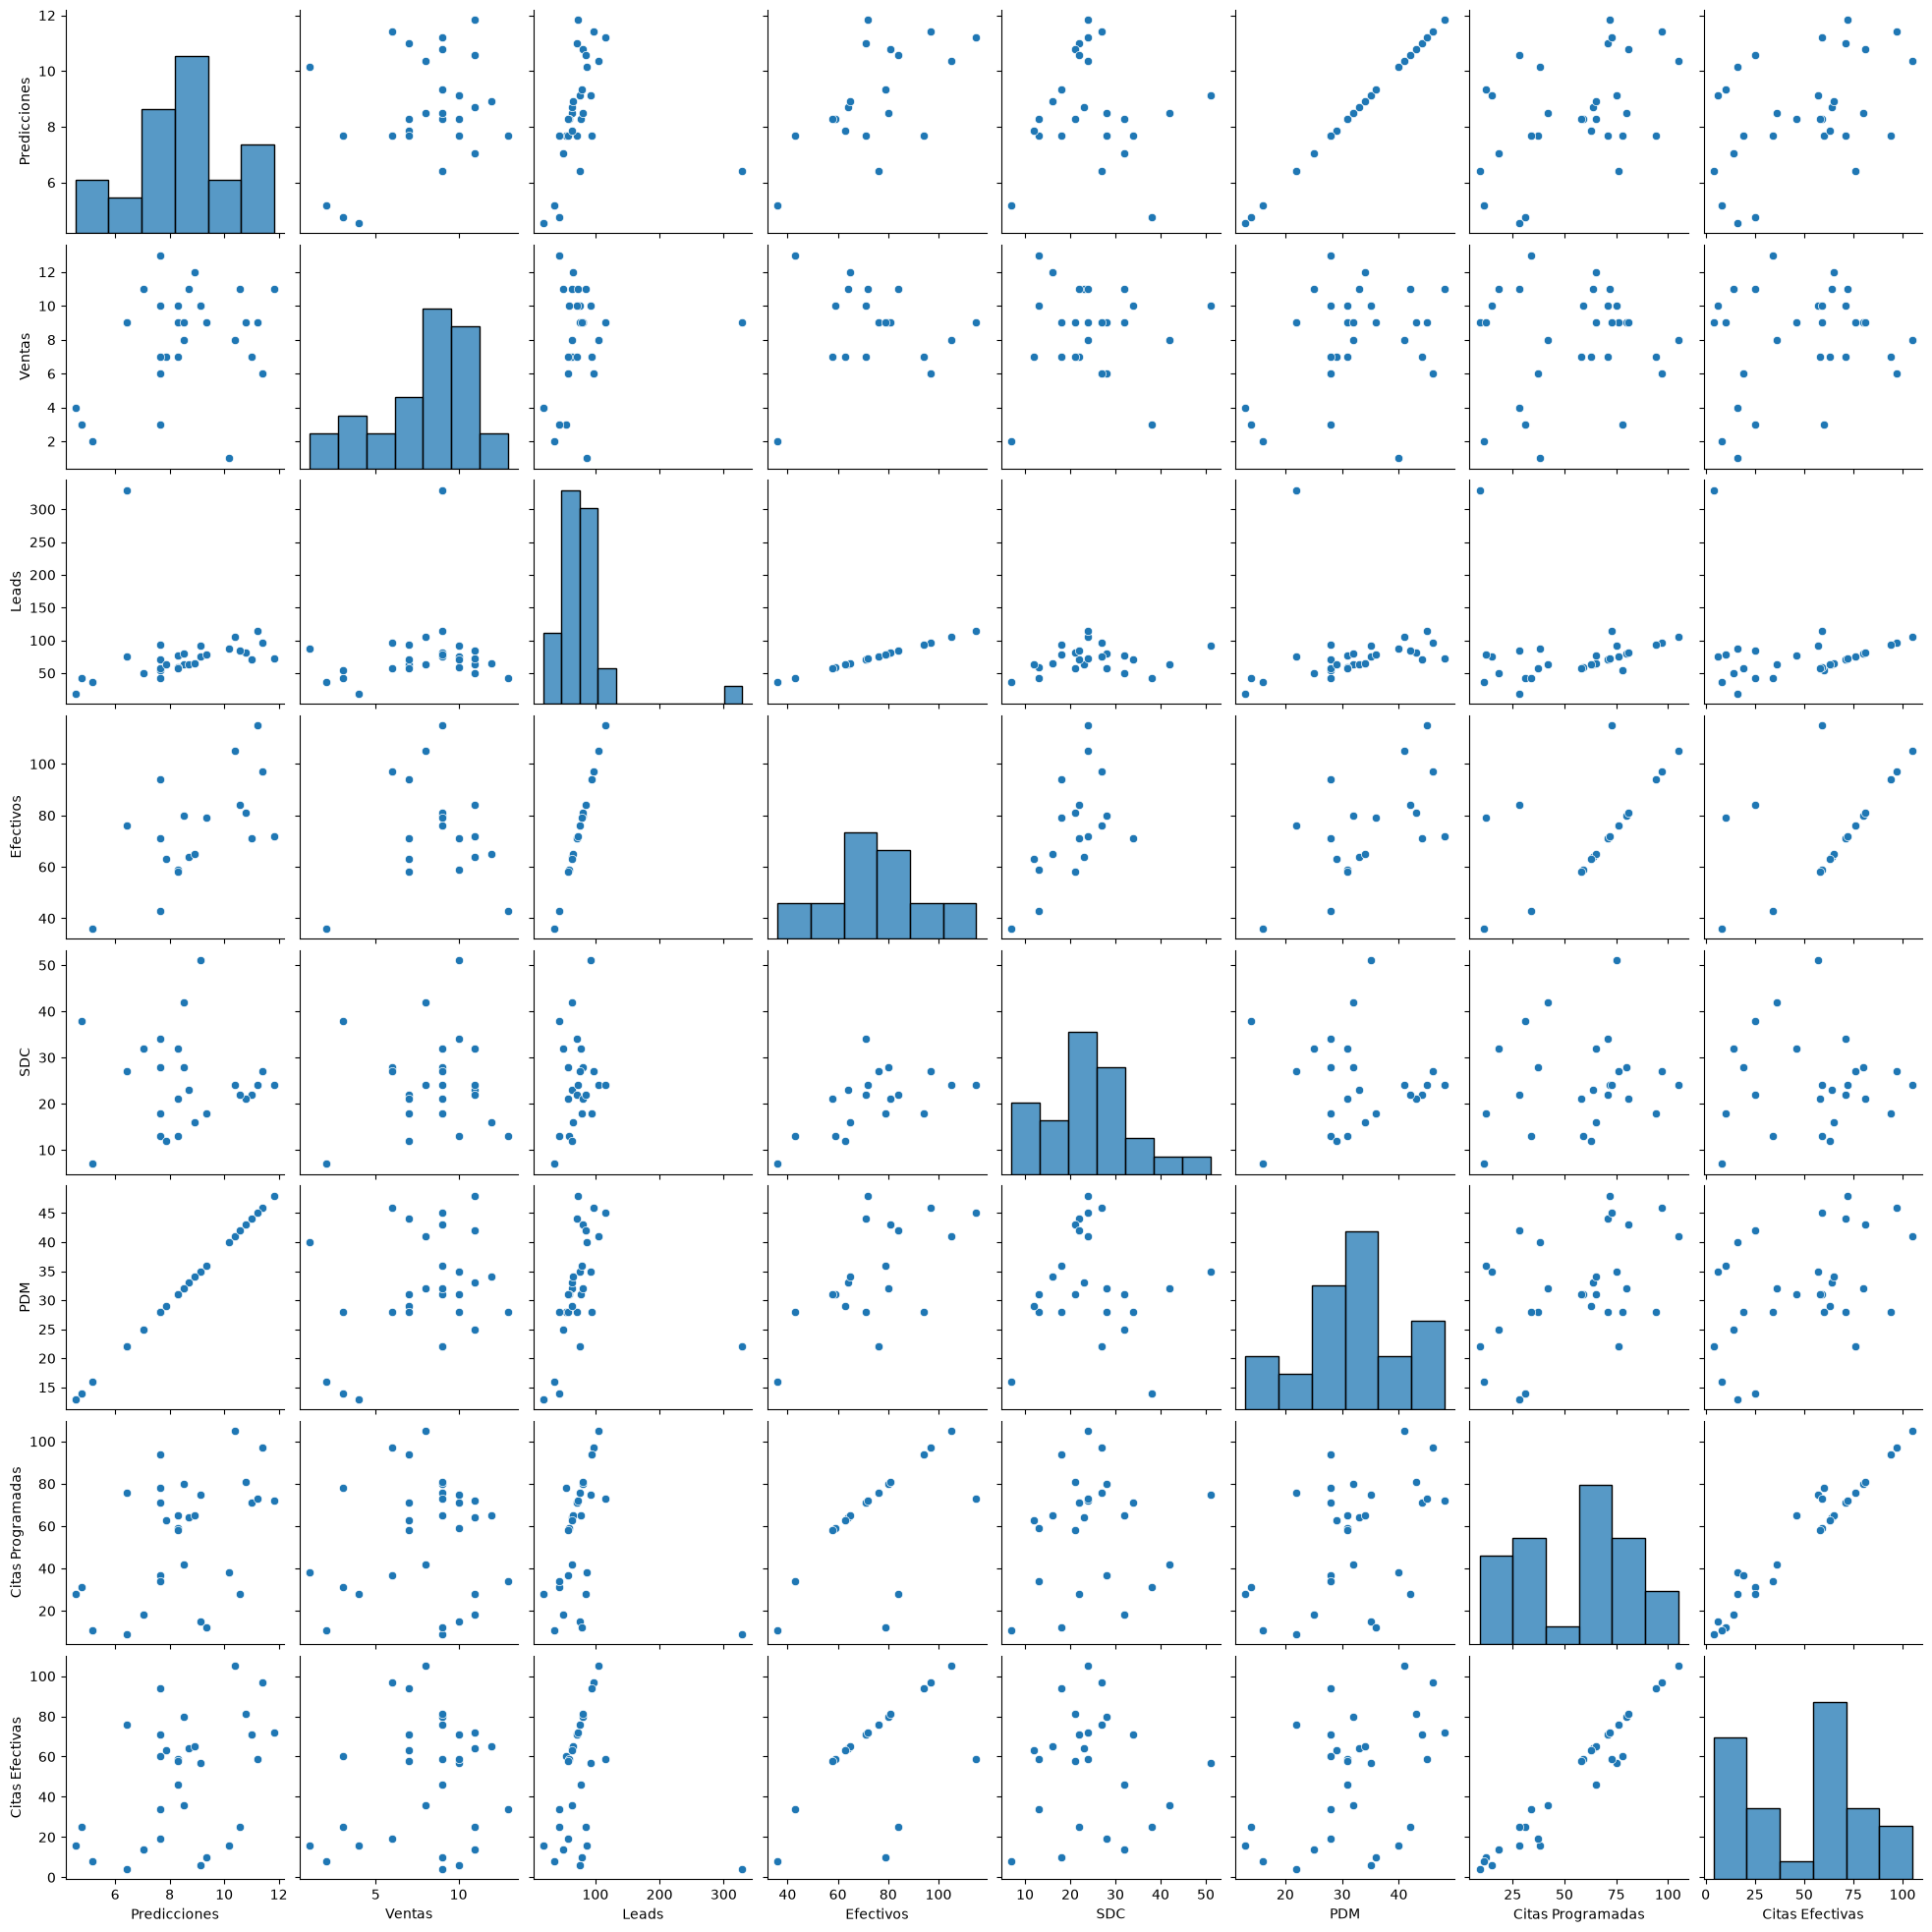

In [291]:
#Graficamos todas las dispersiones entre todas las variables, filtrado por canal
sns.pairplot(piso)

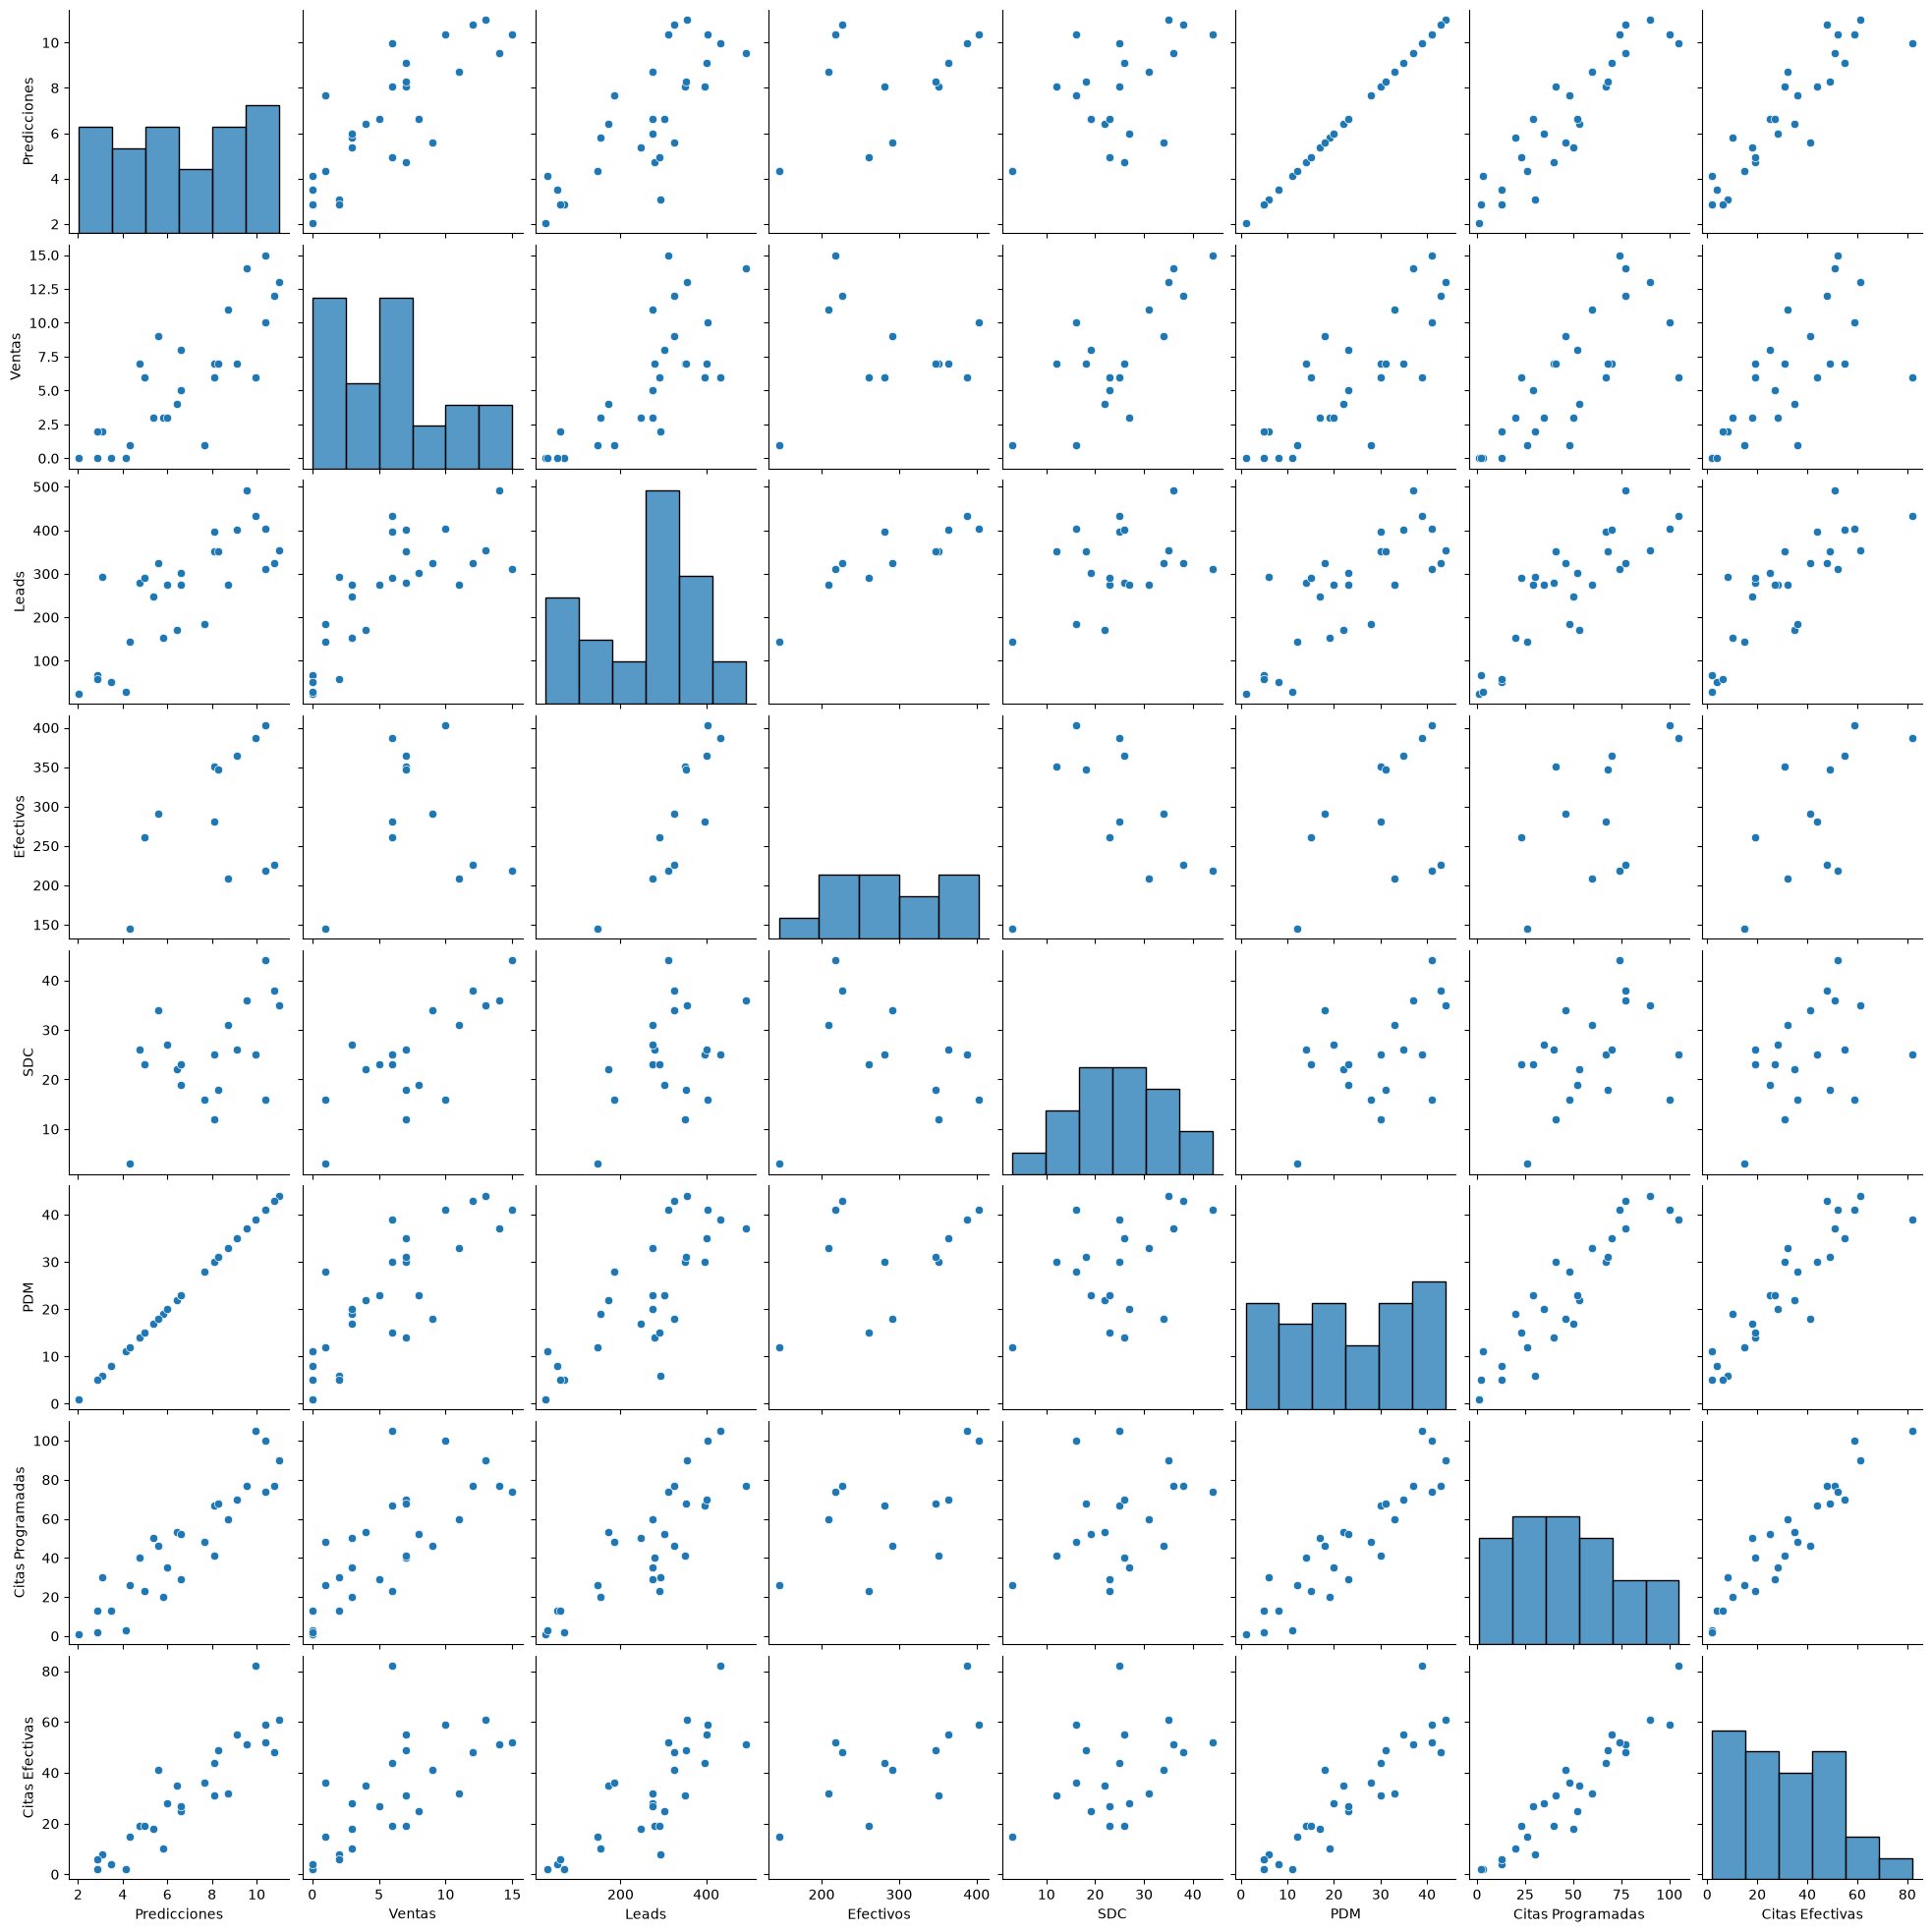

In [292]:
#Graficamos todas las dispersiones entre todas las variables, filtrado por canal
sns.pairplot(plazas)

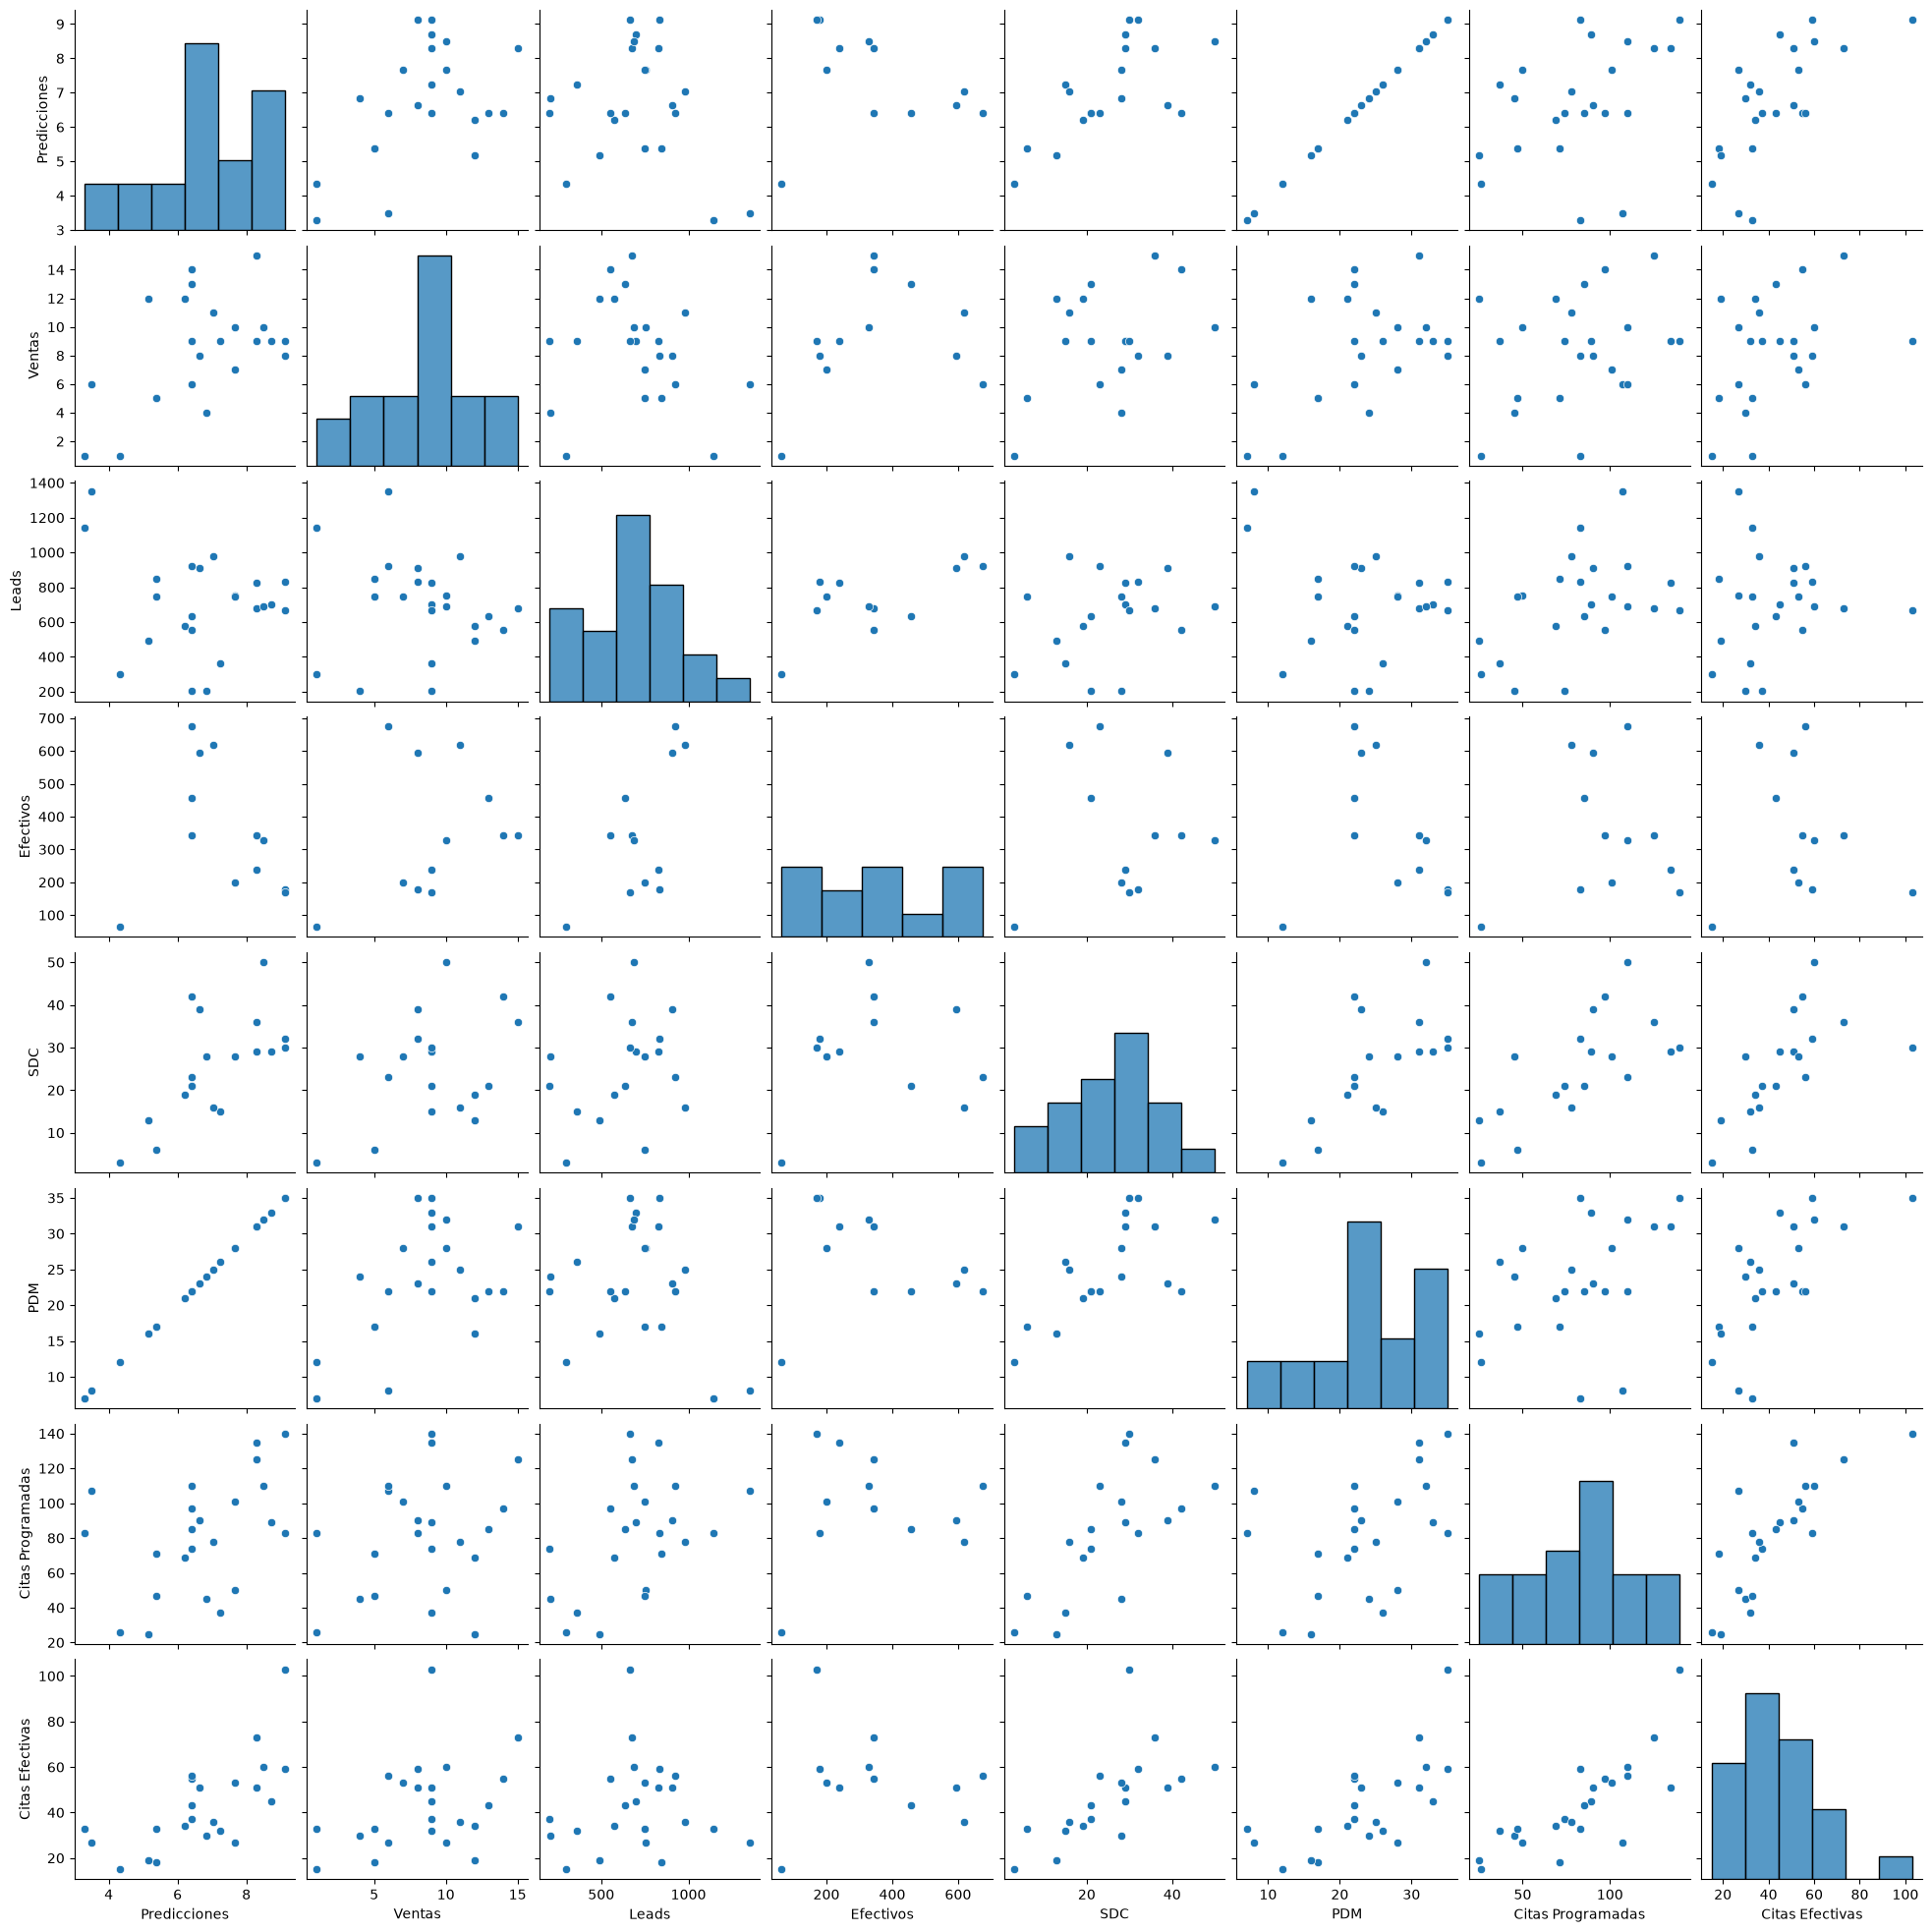

In [293]:
#Graficamos todas las dispersiones entre todas las variables, filtrado por canal
sns.pairplot(digital)

In [294]:
#Encontramos todas las correlaciones entre las variables - piso
variables = ["Predicciones", 'Ventas', 'Leads', 'Efectivos', 'SDC', 'PDM', 'Citas Programadas', 'Citas Efectivas']

corr_piso = piso[variables].corr()
corr_piso

,Predicciones,Ventas,Leads,Efectivos,SDC,PDM,Citas Programadas,Citas Efectivas
Predicciones,1.000000,0.322544,0.107513,0.620435,-0.010433,1.000000,0.458569,0.443342
Ventas,0.322544,1.000000,0.145890,0.016271,0.028472,0.322544,0.088814,0.184617
Leads,0.107513,0.145890,1.000000,0.999933,0.208464,0.107513,-0.068122,-0.064329
Efectivos,0.620435,0.016271,0.999933,1.000000,0.569352,0.620435,0.610394,0.542840
SDC,-0.010433,0.028472,0.208464,0.569352,1.000000,-0.010433,0.123659,-0.005231
PDM,1.000000,0.322544,0.107513,0.620435,-0.010433,1.000000,0.458569,0.443342
Citas Programadas,0.458569,0.088814,-0.068122,0.610394,0.123659,0.458569,1.000000,0.970845
Citas Efectivas,0.443342,0.184617,-0.064329,0.542840,-0.005231,0.443342,0.970845,1.000000


In [295]:
#Encontramos todas las correlaciones entre las variables - plazas
corr_plazas = plazas[variables].corr()
corr_plazas

,Predicciones,Ventas,Leads,Efectivos,SDC,PDM,Citas Programadas,Citas Efectivas
Predicciones,1.000000,0.816677,0.779603,0.395265,0.474937,1.000000,0.914045,0.903136
Ventas,0.816677,1.000000,0.760109,-0.022148,0.758338,0.816677,0.763436,0.701256
Leads,0.779603,0.760109,1.000000,0.865192,0.389000,0.779603,0.840662,0.812444
Efectivos,0.395265,-0.022148,0.865192,1.000000,-0.153417,0.395265,0.554582,0.658534
SDC,0.474937,0.758338,0.389000,-0.153417,1.000000,0.474937,0.381443,0.395948
PDM,1.000000,0.816677,0.779603,0.395265,0.474937,1.000000,0.914045,0.903136
Citas Programadas,0.914045,0.763436,0.840662,0.554582,0.381443,0.914045,1.000000,0.948359
Citas Efectivas,0.903136,0.701256,0.812444,0.658534,0.395948,0.903136,0.948359,1.000000


In [296]:
#Encontramos todas las correlaciones entre las variables - digital
corr_digital = digital[variables].corr()
corr_digital

,Predicciones,Ventas,Leads,Efectivos,SDC,PDM,Citas Programadas,Citas Efectivas
Predicciones,1.000000,0.494265,-0.203956,-0.195452,0.662097,1.000000,0.429418,0.683957
Ventas,0.494265,1.000000,-0.141695,0.291185,0.402287,0.494265,0.271744,0.371175
Leads,-0.203956,-0.141695,1.000000,0.661593,0.277646,-0.203956,0.471118,0.099760
Efectivos,-0.195452,0.291185,0.661593,1.000000,0.090996,-0.195452,0.088163,-0.096636
SDC,0.662097,0.402287,0.277646,0.090996,1.000000,0.662097,0.685919,0.648368
PDM,1.000000,0.494265,-0.203956,-0.195452,0.662097,1.000000,0.429418,0.683957
Citas Programadas,0.429418,0.271744,0.471118,0.088163,0.685919,0.429418,1.000000,0.793517
Citas Efectivas,0.683957,0.371175,0.099760,-0.096636,0.648368,0.683957,0.793517,1.000000


<Axes: >

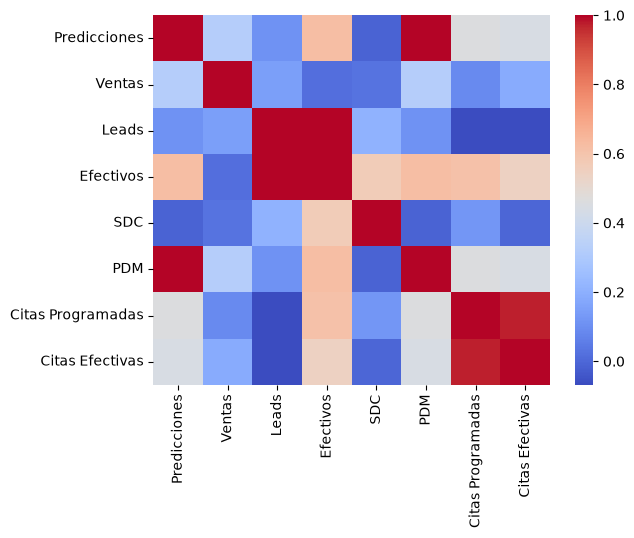

In [297]:
#Graficamos el mapa de calor de los coeficientes de correlación - piso
Heat_Map= sns.heatmap(corr_piso, cmap = 'coolwarm')  
Heat_Map

<Axes: >

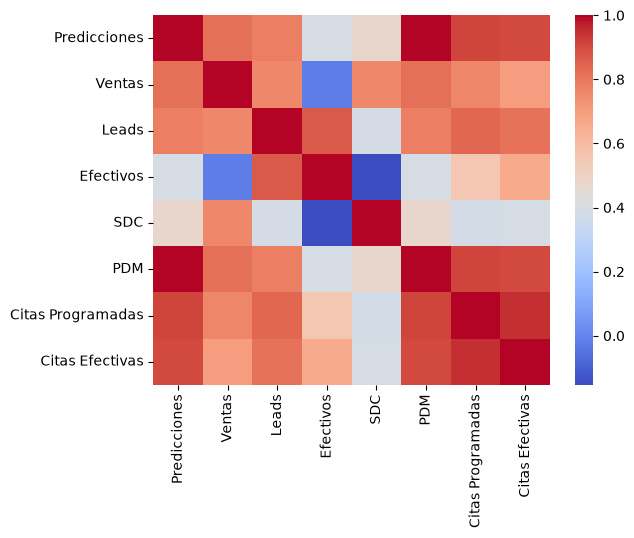

In [298]:
#Graficamos el mapa de calor de los coeficientes de correlación - plazas
Heat_Map= sns.heatmap(corr_plazas, cmap = 'coolwarm')  
Heat_Map

<Axes: >

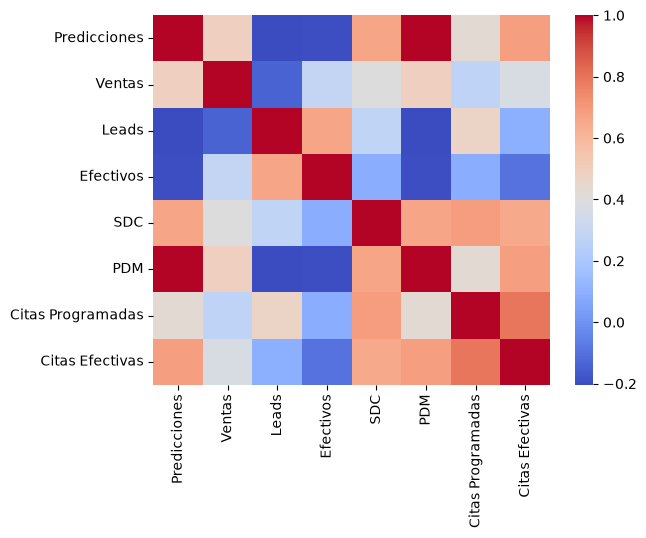

In [299]:
#Graficamos el mapa de calor de los coeficientes de correlación - digital
Heat_Map= sns.heatmap(corr_digital, cmap = 'coolwarm')  
Heat_Map

<Axes: >

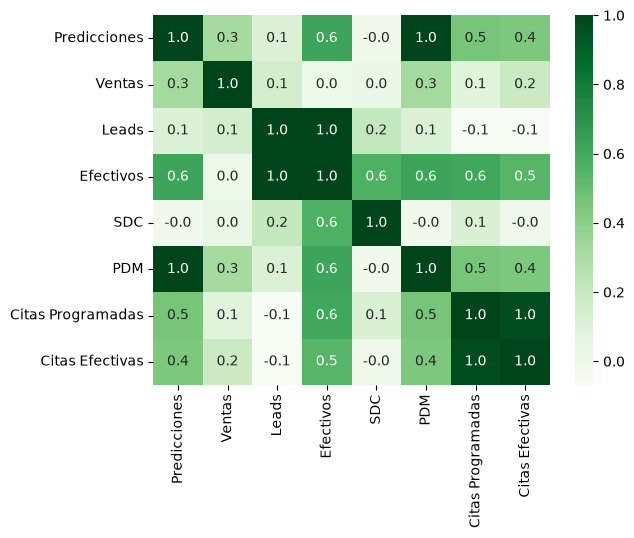

In [300]:
#Ajustamos el mapa de calor de los coeficientes de correlación - piso
Heat_Map= sns.heatmap(corr_piso, cmap = 'Greens', annot=True, fmt=".1f")  
Heat_Map

<Axes: >

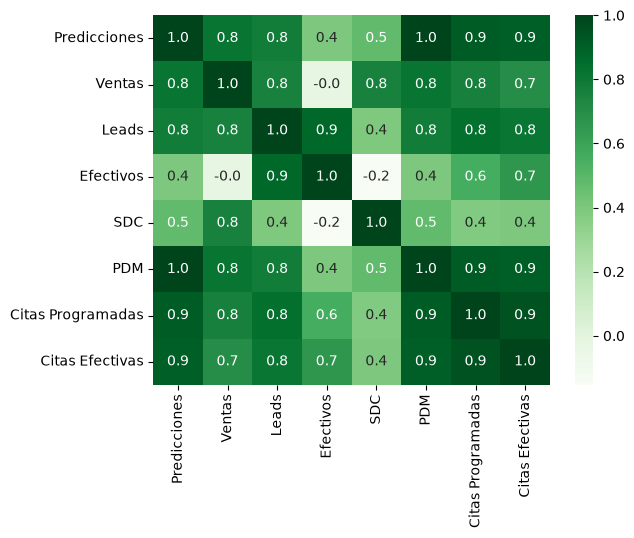

In [301]:
#Ajustamos el mapa de calor de los coeficientes de correlación - plazas
Heat_Map= sns.heatmap(corr_plazas, cmap = 'Greens', annot=True, fmt=".1f")  
Heat_Map

<Axes: >

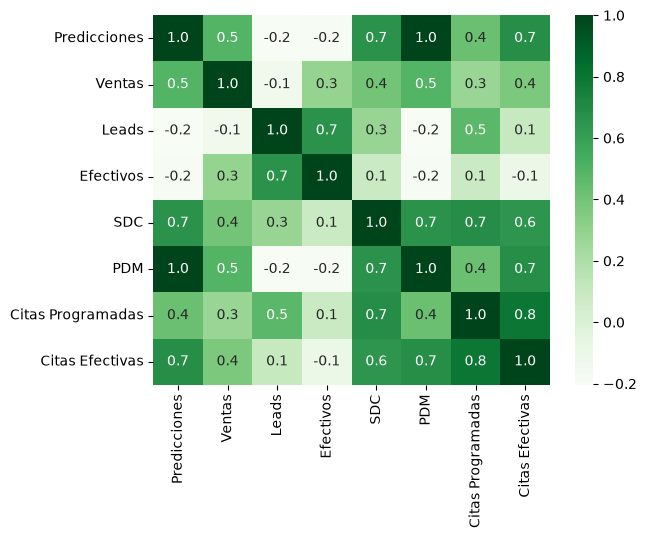

In [302]:
#Ajustamos el mapa de calor de los coeficientes de correlación - digital
Heat_Map= sns.heatmap(corr_digital, cmap = 'Greens', annot=True, fmt=".1f")  
Heat_Map